<h1 align="center">2 домашнее задание</h1>
<p align="center">Иван Фомин, ПАДИИ</p>

Я выбрал корпус Mushrooms Classifications Dataset с Kaggle. Там нужно решить задачу бинарной классификации (определить, съедобный гриб или ядовитый).

In [159]:
# Подавление предупреждений
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

import pandas as pd
import numpy as np
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
import torch
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
from torch.utils.data import Dataset as TorchDataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os


df = pd.read_csv("data/mushrooms.csv")
print("Уникальные значения в признаках:")
for col in df.columns[10:13]:
    print(f"{col}: {df[col].unique()}")

print("\n")
df = df.replace('?', 'u')
print(df[df.columns[11]].unique())
print("\nРазмерность признаков:", df.shape)

Уникальные значения в признаках:
stalk-shape: <StringArray>
['e', 't']
Length: 2, dtype: str
stalk-root: <StringArray>
['e', 'c', 'b', 'r', '?']
Length: 5, dtype: str
stalk-surface-above-ring: <StringArray>
['s', 'f', 'k', 'y']
Length: 4, dtype: str


<StringArray>
['e', 'c', 'b', 'r', 'u']
Length: 5, dtype: str

Размерность признаков: (8124, 23)


В данных все признаки категориальные. В одной из колонок есть '?' (в качестве NaN, которых здесь вообще нет).

In [160]:

# Кодируем целевую переменную (бинарная классификация)
le_target = LabelEncoder()
df['class_encoded'] = le_target.fit_transform(df['class']) # 'e' -> 0, 'p' -> 1

# Кодируем признаки
feature_encoders = {}
X = pd.DataFrame()

for col in df.columns:
    if col not in ['class', 'class_encoded']:
        le = LabelEncoder()
        X[col] = le.fit_transform(df[col])
        feature_encoders[col] = le # Сохраняем для будущего использования

y = df['class_encoded'].values
print("\nРазмерность признаков:", X.shape)

# Разделяем данные до создания Dataset (важно для корректной оценки)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Создаём словари для Dataset
train_dict = {col: X_train[col].values for col in X_train.columns}
train_dict['label'] = y_train

test_dict = {col: X_test[col].values for col in X_test.columns}
test_dict['label'] = y_test

# Создаём Dataset объекты
train_dataset = Dataset.from_dict(train_dict)
test_dataset = Dataset.from_dict(test_dict)

# Объединяем в DatasetDict для удобства
dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

print("\nПример объекта из train:")
print(dataset["train"][0])


Размерность признаков: (8124, 22)

Пример объекта из train:
{'cap-shape': 2, 'cap-surface': 3, 'cap-color': 9, 'bruises': 0, 'odor': 2, 'gill-attachment': 1, 'gill-spacing': 0, 'gill-size': 0, 'gill-color': 2, 'stalk-shape': 0, 'stalk-root': 0, 'stalk-surface-above-ring': 1, 'stalk-surface-below-ring': 1, 'stalk-color-above-ring': 6, 'stalk-color-below-ring': 0, 'veil-type': 0, 'veil-color': 2, 'ring-number': 1, 'ring-type': 2, 'spore-print-color': 1, 'population': 5, 'habitat': 1, 'label': 1}


In [ ]:
class MushroomClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), # 1 слой
            nn.BatchNorm1d(hidden_dim),
            nn.PReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_dim, hidden_dim // 2), # 2 слой
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ELU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim // 2, 1) # бинарная классификация, 1 выход
        )
    
    def forward(self, x):
        return self.model(x).squeeze(-1)


# Подготовка загрузчиков
class MushroomTorchDataset(TorchDataset):
    def __init__(self, hf_dataset):
        self.features = torch.tensor(
            np.stack([hf_dataset[col] for col in hf_dataset.column_names if col != 'label'], axis=1), # Матрица признаков
            dtype=torch.float32
        )
        self.labels = torch.tensor(hf_dataset['label'], dtype=torch.float32) # Вектор меток
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_torch = MushroomTorchDataset(dataset['train'])
test_torch = MushroomTorchDataset(dataset['test'])

train_loader = DataLoader(train_torch, batch_size=64, shuffle=True)
test_loader = DataLoader(test_torch, batch_size=256)

# Инициализация
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MushroomClassifier(input_dim=X.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss() # лучшая для бинарной классификации
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # самый стабильный
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3)

# TensorBoard
writer = SummaryWriter(log_dir="runs/mushroom_classification")
os.makedirs("models", exist_ok=True)

# Цикл обучения
best_acc = 0.0
epoch_test_loss = []
for epoch in range(10):
    # Обучение
    model.train()
    train_loss, train_preds, train_targets = 0.0, [], []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).float()
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(y_batch.cpu().numpy())
    
    train_acc = accuracy_score(train_targets, train_preds)
    
    # Валидация
    model.eval()
    test_loss, test_preds, test_targets, test_probs = 0.0, [], [], []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            
            test_loss += loss.item()
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(float)
            
            test_preds.extend(preds)
            test_targets.extend(y_batch.cpu().numpy())
            test_probs.extend(probs)
    
    test_acc = accuracy_score(test_targets, test_preds)
    
    # Логирование
    writer.add_scalar('Loss/train', train_loss / len(train_loader), epoch)
    writer.add_scalar('Loss/test', test_loss / len(test_loader), epoch)
    writer.add_scalar('Accuracy/train', train_acc, epoch)
    writer.add_scalar('Accuracy/test', test_acc, epoch)
    
    print(f"Epoch {epoch+1:2d} | Train loss: {train_loss/len(train_loader):.4f}, acc: {train_acc:.4f} | "
          f"Test loss: {test_loss/len(test_loader):.4f}, acc: {test_acc:.4f}")
    
    # Сохранение лучшей модели
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "models/best_model.pth")
        print(f" Сохранена новая лучшая модель (точность: {test_acc:.4f})")
    
    scheduler.step(test_acc)
    epoch_test_loss.append(test_loss)

writer.close()
print(f"\nЛучшая точность на тесте: {best_acc:.4f}")

Epoch  1 | Train loss: 0.3895, acc: 0.8387 | Test loss: 0.2270, acc: 0.9102
  → Сохранена новая лучшая модель (точность: 0.9102)
Epoch  2 | Train loss: 0.1772, acc: 0.9343 | Test loss: 0.0846, acc: 0.9692
  → Сохранена новая лучшая модель (точность: 0.9692)
Epoch  3 | Train loss: 0.0931, acc: 0.9714 | Test loss: 0.0363, acc: 0.9957
  → Сохранена новая лучшая модель (точность: 0.9957)
Epoch  4 | Train loss: 0.0562, acc: 0.9826 | Test loss: 0.0198, acc: 0.9975
  → Сохранена новая лучшая модель (точность: 0.9975)
Epoch  5 | Train loss: 0.0396, acc: 0.9886 | Test loss: 0.0140, acc: 0.9969
Epoch  6 | Train loss: 0.0268, acc: 0.9925 | Test loss: 0.0088, acc: 1.0000
  → Сохранена новая лучшая модель (точность: 1.0000)
Epoch  7 | Train loss: 0.0219, acc: 0.9938 | Test loss: 0.0052, acc: 1.0000
Epoch  8 | Train loss: 0.0163, acc: 0.9957 | Test loss: 0.0036, acc: 1.0000
Epoch  9 | Train loss: 0.0151, acc: 0.9955 | Test loss: 0.0032, acc: 1.0000
Epoch 10 | Train loss: 0.0122, acc: 0.9968 | Test l

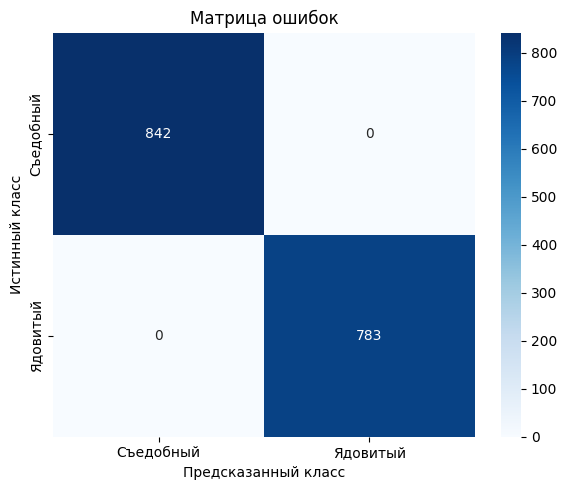

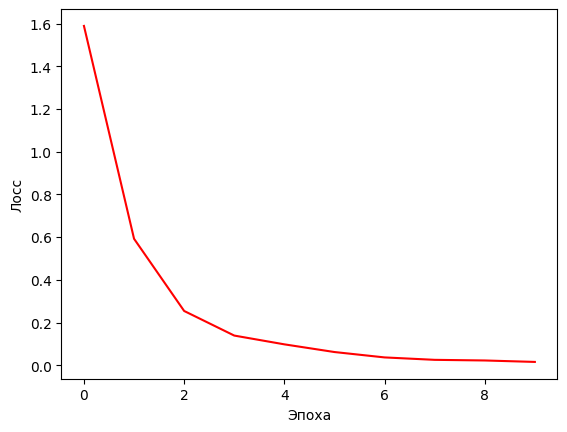

In [165]:
# Загрузка лучшей модели
model.load_state_dict(torch.load("models/best_model.pth"))
model.eval()

# Получение предсказаний на тесте
all_preds, all_targets, all_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(float)
        
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())
        all_probs.extend(probs)

# Матрица ошибок
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Съедобный', 'Ядовитый'],
            yticklabels=['Съедобный', 'Ядовитый'])
plt.title('Матрица ошибок')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

plt.plot(epoch_test_loss, c='r')
plt.ylabel('Лосс')
plt.xlabel('Эпоха')
plt.show()


In [163]:
# Пример нового гриба (взят из тестовой выборки)
sample_idx = 0
sample_features = X_test.iloc[sample_idx].values.astype(np.float32)
sample_tensor = torch.tensor(sample_features).unsqueeze(0).to(device)

with torch.no_grad():
    logit = model(sample_tensor)
    prob = torch.sigmoid(logit).item()

pred_class = "ЯДОВИТЫЙ" if prob > 0.5 else "съедобный"
true_class = "ЯДОВИТЫЙ" if y_test[sample_idx] else "съедобный"

print(f"\nДемонстрация на примере:")
print(f"  Истинный класс: {true_class}")
print(f"  Предсказание модели: {pred_class}")
print(f"  Вероятность ядовитости: {prob:.2%}")


Демонстрация на примере:
  Истинный класс: ЯДОВИТЫЙ
  Предсказание модели: ЯДОВИТЫЙ
  Вероятность ядовитости: 99.88%


In [164]:
print("=== Logistic Regression ===")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Точность: {acc_lr:.4f}")

print("\n=== XGBoost ===")
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Точность: {acc_xgb:.4f}")

print("\n=== Random Forest ===")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Точность: {acc_rf:.4f}")

=== Logistic Regression ===
Точность: 0.9582

=== XGBoost ===
Точность: 1.0000

=== Random Forest ===
Точность: 1.0000


Ниже я попытаюсь написать какие-то выводы по этому коду.

Сначала я заменил все '?' на 'u' (unknown) для того, чтобы закодировать все категориальные данные через LabelEncoder.

Судя по всему, я выбрал простые данные, потому что в том числе и алгоритмы классического машинного обучения справляются почти со 100% точностью.

На лекции вы очень рекомендовали пробовать разные функции активации (и даже назначать отдельную на каждый слой), но я попробовал несколько разных $-$ все дают один и тот же score = 1.0. Да и зачем их менять, если и так всё идеально работает... В следующий раз (если он будет) постараюсь выбрать более интересные данные.

В целом, можно было бы вместо train_test_split провести кросс-валидацию.